# Compare neural operators for linear elasticity problem

Run in **`neuralopv2`** after training DeepONet, PCANet, and FNO (`training_and_testing.ipynb` in each folder).

Writes test samples `[27, 47, 43, 80, 5]` to `compare_nops/` and assembles a comparison montage. 

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys

import numpy as np
import torch

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "..", "..", ".."))
sys.path.insert(0, os.path.join(ROOT, "src/plotting"))
sys.path.insert(0, os.path.join(ROOT, "src/data"))
sys.path.insert(0, os.path.join(ROOT, "src/nn"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/deeponet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/mlp"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/pcanet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/fno"))
sys.path.insert(0, os.path.join(ROOT, "src/mcmc")) # needed for nn/nn_util.py to load correctly

from field_plot import field_plot, field_plot_grid, quick_field_plot, quick_field_plot_grid
from plot_mix_collection import *
from point_plot import *
from dataMethods import DataProcessor
from load_data_and_deeponet import load_data_and_deeponet
from load_data_and_pcanet import load_data_and_pcanet
from load_data_and_fno import load_data_and_fno
from nn_util import load_data_and_model

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

seed = 0
np.random.seed(seed)
_ = torch.manual_seed(seed)


In [2]:
data_folder = '../data/'
current_directory = os.getcwd()  
results_dir = current_directory + '/' + data_folder
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Load neural operators

In [3]:
deeponet_data, deeponet = load_data_and_model('DeepONet', 'LinearElasticity', '../')
pcanet_data, pcanet = load_data_and_model('PCANet', 'LinearElasticity', '../')
fno_data, fno = load_data_and_model('FNO', 'LinearElasticity', '../')

# Evaluate the models on testing data

In [4]:
# DeepONet predictions
deeponet_Y_test_pred = deeponet.predict(deeponet_data.X_test, deeponet_data.X_trunk).detach().numpy()

deeponet_Y_test_error = np.linalg.norm(deeponet_data.Y_test - deeponet_Y_test_pred, axis = 1)/np.linalg.norm(deeponet_data.Y_test, axis = 1)

print('Num tests: {:5d}, Mean Loss (rel l2): {:.3e}, Std Loss (rel l2): {:.3e}'.format(len(deeponet_data.Y_test), np.mean(deeponet_Y_test_error), np.std(deeponet_Y_test_error)))

Num tests:   800, Mean Loss (rel l2): 7.389e-02, Std Loss (rel l2): 3.974e-02


In [5]:
# PCANet predictions
pcanet_Y_test_pred = pcanet.predict(pcanet_data.X_test).detach().numpy()

pcanet_Y_test_error = np.linalg.norm(pcanet_data.Y_test - pcanet_Y_test_pred, axis = 1)/np.linalg.norm(pcanet_data.Y_test, axis = 1)

print('Num tests: {:5d}, Mean Loss (rel l2): {:.3e}, Std Loss (rel l2): {:.3e}'.format(len(pcanet_data.Y_test), np.mean(pcanet_Y_test_error), np.std(pcanet_Y_test_error)))

Num tests:   800, Mean Loss (rel l2): 1.931e-02, Std Loss (rel l2): 1.095e-02


In [6]:
# FNO predictions
fno_Y_test_pred = fno.predict(fno_data.X_test).detach().numpy()

a = fno_data.Y_test.reshape(fno_data.Y_test.shape[0], -1)
b = fno_Y_test_pred.reshape(fno_Y_test_pred.shape[0], -1)

fno_Y_test_error = np.linalg.norm(a - b, axis = 1)/np.linalg.norm(a, axis = 1)

print('Num tests: {:5d}, Mean Loss (rel l2): {:.3e}, Std Loss (rel l2): {:.3e}'.format(len(a), np.mean(fno_Y_test_error), np.std(fno_Y_test_error)))

Num tests:   800, Mean Loss (rel l2): 5.111e-02, Std Loss (rel l2): 2.324e-02


/var/folders/tt/zt64sf2n4kgfkx71d8pf39440000gn/T/ipykernel_61596/2038116392.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fno_Y_test_error = np.linalg.norm(a - b, axis = 1)/np.linalg.norm(a, axis = 1)


## Plotting

In [7]:
def apply_dirichlet_bc(u, bc_value, bc_node_ids, num_nodes=None):
    # FEniCSx P1 vector layout: [ux(v0), uy(v0), ux(v1), uy(v1), ...]
    if num_nodes is None:
        num_nodes = u.shape[0] // 2
    u_xy = u.reshape(num_nodes, 2)
    u_xy[bc_node_ids, :] = bc_value
    return u_xy.reshape(-1)

def apply_grid_dirichlet_bc(u, bc_value, bc_node_ids):
    u[bc_node_ids[:, 0], bc_node_ids[:, 1], 0] = bc_value
    u[bc_node_ids[:, 0], bc_node_ids[:, 1], 1] = bc_value
    return u


In [8]:
i_choices = [27, 47, 43, 80,  5] #, 46, 14, 66,  2, 79]

In [9]:
plot_dir = 'nops_comparison_plots/'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)


nodes = deeponet_data.X_trunk
num_nodes = nodes.shape[0]
grid_x, grid_y = fno_data.grid_x_test[0], fno_data.grid_y_test[0]
cmaps = ['jet', 'jet', 'hot']

plt.ioff()
for i in i_choices:
    print('i = ', i)
    
    print('  save m')
    i_m = deeponet_data.decoder_X(deeponet_data.X_test[i])
   
    quick_field_plot(i_m, nodes, cmap = cmaps[0], \
                     savefilename = '{}/m_{}.png'.format(plot_dir, i), show_plot = False)
    plt.close()

    print('  save true u')
    i_u = deeponet_data.decoder_Y(deeponet_data.Y_test[i])
    quick_field_plot(i_u, nodes, cmap = cmaps[1], \
                      savefilename = '{}/u_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = True, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()

    print('  save DeepONet u')
    i_u_deeponet = deeponet_data.decoder_Y(deeponet_Y_test_pred[i])
    apply_dirichlet_bc(i_u_deeponet, 0.0, deeponet_data.u_mesh_dirichlet_boundary_nodes, num_nodes)
    quick_field_plot(i_u_deeponet, nodes, cmap = cmaps[1], \
                      savefilename = '{}/u_deeponet_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = True, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()

    print('  save DeepONet error')
    i_u_deeponet_error = i_u - i_u_deeponet
    quick_field_plot(i_u_deeponet_error, nodes, cmap = cmaps[2], \
                      savefilename = '{}/u_deeponet_error_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = False, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()

    i_u_deeponet_error_norm = np.linalg.norm(i_u - i_u_deeponet)/np.linalg.norm(i_u)    
    np.savetxt('{}/u_deeponet_error_norm_{}.txt'.format(plot_dir, i), np.array([i_u_deeponet_error_norm]))

    print('  save PCANet u')
    i_u_pcanet = pcanet_data.decoder_Y(pcanet_Y_test_pred[i])
    apply_dirichlet_bc(i_u_pcanet, 0.0, pcanet_data.u_mesh_dirichlet_boundary_nodes, num_nodes)
    quick_field_plot(i_u_pcanet, nodes, cmap = cmaps[1], \
                      savefilename = '{}/u_pcanet_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = True, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()

    print('  save PCANet error')
    i_u_pcanet_error = i_u - i_u_pcanet
    quick_field_plot(i_u_pcanet_error, nodes, cmap = cmaps[2], \
                      savefilename = '{}/u_pcanet_error_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = False, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()
    
    i_u_pcanet_error_norm = np.linalg.norm(i_u - i_u_pcanet)/np.linalg.norm(i_u)
    np.savetxt('{}/u_pcanet_error_norm_{}.txt'.format(plot_dir, i), np.array([i_u_pcanet_error_norm]))

    print('  save FNO u')
    i_u_grid = fno_data.decoder_Y(fno_data.Y_test[i])
    i_u_fno = fno_data.decoder_Y(fno_Y_test_pred[i])
    apply_grid_dirichlet_bc(i_u_fno, 0.0, fno_data.u_grid_dirichlet_boundary_nodes)
    quick_field_plot_grid(i_u_fno, grid_x, grid_y, cmap = cmaps[1], \
                      savefilename = '{}/u_fno_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = True, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()

    print('  save FNO error')
    i_u_fno_error = i_u_grid - i_u_fno
    quick_field_plot_grid(i_u_fno_error, grid_x, grid_y, cmap = cmaps[2], \
                      savefilename = '{}/u_fno_error_{}.png'.format(plot_dir, i), show_plot = False, \
                        add_displacement_to_nodes = False, \
                        is_displacement = True, vector_layout = 'mixed')
    plt.close()

    i_u_fno_error_norm = np.linalg.norm(i_u_grid - i_u_fno)/np.linalg.norm(i_u_grid)
    np.savetxt('{}/u_fno_error_norm_{}.txt'.format(plot_dir, i), np.array([i_u_fno_error_norm]))





i =  27
  save m
  save true u
  save DeepONet u
  save DeepONet error
  save PCANet u
  save PCANet error
  save FNO u
  save FNO error
i =  47
  save m
  save true u
  save DeepONet u


/var/folders/tt/zt64sf2n4kgfkx71d8pf39440000gn/T/ipykernel_61596/1622481093.py:81: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  i_u_fno_error = i_u_grid - i_u_fno
/var/folders/tt/zt64sf2n4kgfkx71d8pf39440000gn/T/ipykernel_61596/1622481093.py:88: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  i_u_fno_error_norm = np.linalg.norm(i_u_grid - i_u_fno)/np.linalg.norm(i_u_grid)


  save DeepONet error
  save PCANet u
  save PCANet error
  save FNO u
  save FNO error
i =  43
  save m
  save true u
  save DeepONet u
  save DeepONet error
  save PCANet u
  save PCANet error
  save FNO u
  save FNO error
i =  80
  save m
  save true u
  save DeepONet u
  save DeepONet error
  save PCANet u
  save PCANet error
  save FNO u
  save FNO error
i =  5
  save m
  save true u
  save DeepONet u
  save DeepONet error
  save PCANet u
  save PCANet error
  save FNO u
  save FNO error


# plot the results

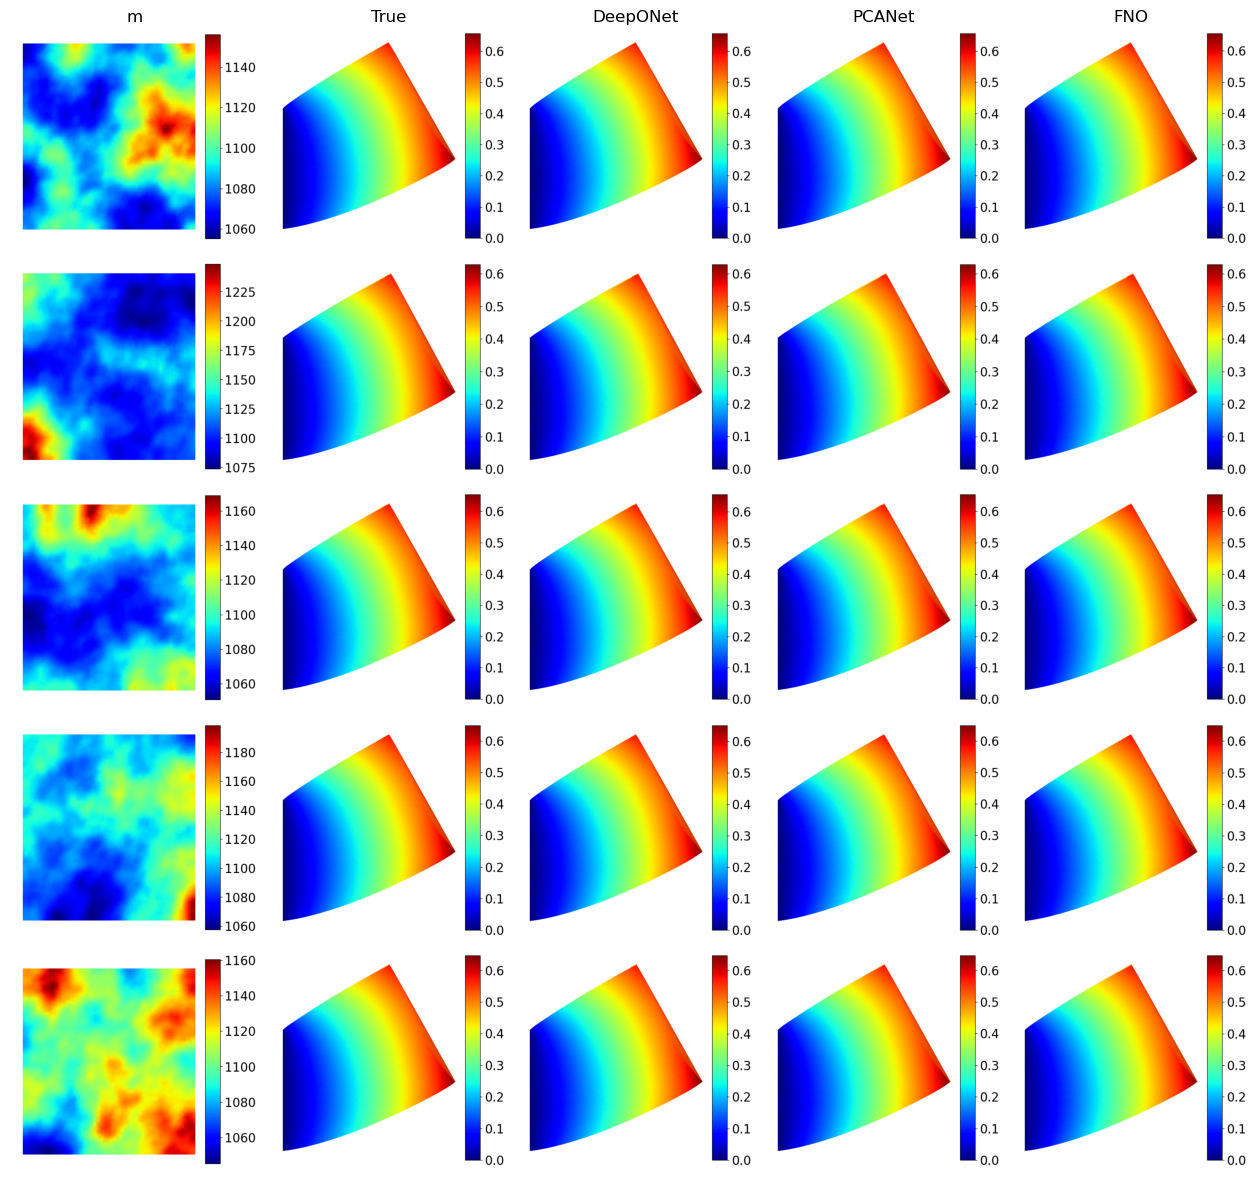

In [10]:
fig = plt.figure(figsize=(16, 16))
grid = ImageGrid(fig, 111,
                 nrows_ncols=(len(i_choices), 5),
                 axes_pad=0.1,
                 )

imgs = []
for i in range(len(i_choices)):
    imgs.append(plt.imread('{}/m_{}.png'.format(plot_dir, i_choices[i])))
    imgs.append(plt.imread('{}/u_{}.png'.format(plot_dir, i_choices[i])))
    imgs.append(plt.imread('{}/u_deeponet_{}.png'.format(plot_dir, i_choices[i])))
    imgs.append(plt.imread('{}/u_pcanet_{}.png'.format(plot_dir, i_choices[i])))
    imgs.append(plt.imread('{}/u_fno_{}.png'.format(plot_dir, i_choices[i])))

counter = 0
lbls = ['m', 'True', 'DeepONet', 'PCANet', 'FNO']
for ax, im in zip(grid, imgs):
    # Iterating over the grid returns the Axes.
    ax.imshow(im)
    ax.axis('off')
    if counter < len(i_choices):
        ax.set_title(lbls[counter%5])
    counter += 1

    
plt.savefig('{}/nops_comparison_plots.png'.format(plot_dir), dpi = 300) ;  
plt.show()